# SQL Question-Answer Model Training

This notebook trains an encoder-decoder model to generate answers from questions using SQL query results data.

**Model Architecture:**
- LSTM Encoder for questions
- LSTM Decoder for answers
- Seq2seq with teacher forcing

**Data:** QueryResults(1).csv, QueryResults(4).csv, QueryResults(5).csv

## 1. Import Required Libraries

In [1]:
import sys
import os

# Add src directory to path
sys.path.append('../src')

import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Import custom modules
from config_sql import *
from preprocess_sql import preprocess_sql_qa_pipeline
from vocabulary_sql import create_qa_vocabularies, tokenize_text
from dataset_sql import create_qa_dataloader
from model_sql import create_qa_model
from inference_sql import generate_answer

print(f"PyTorch Version: {torch.__version__}")
print(f"Device: {DEVICE}")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/usr/lib64/python3.11/runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/usr/lib64/python3.11/runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "/home/compute.ashesi.lan/jason.darko/python-env/lib64/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/compute.ashesi.lan/jason.darko/python-env/lib64/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
   

PyTorch Version: 2.0.0+cu117
Device: cuda:0


## 2. Load and Preprocess Data

Aggregate all QueryResults CSV files and clean the question-answer pairs.

In [2]:
# Run preprocessing pipeline
train_df, test_df, all_df = preprocess_sql_qa_pipeline()

print(f"\n📊 Dataset Statistics:")
print(f"Total Q&A pairs: {len(all_df)}")
print(f"Training set: {len(train_df)}")
print(f"Test set: {len(test_df)}")

SQL QUESTION-ANSWER PREPROCESSING PIPELINE
Loading QueryResults(1).csv...
  Loaded 50000 rows
Loading QueryResults(4).csv...
  Loaded 45636 rows
Loading QueryResults(5).csv...
  Loaded 20646 rows

Total rows after aggregation: 116282
Columns: ['QuestionId', 'Title', 'QuestionBody', 'QuestionScore', 'CreationDate', 'Tags', 'AcceptedAnswerId', 'AnswerCount', 'AnswerId', 'AnswerBody', 'AnswerScore']

Filtering valid Q&A pairs...
Available columns: ['QuestionId', 'Title', 'QuestionBody', 'QuestionScore', 'CreationDate', 'Tags', 'AcceptedAnswerId', 'AnswerCount', 'AnswerId', 'AnswerBody', 'AnswerScore']
Question column: 'QuestionBody'
Answer column: 'AnswerBody'

Valid Q&A pairs after filtering: 116279
Average question length: 1340.4 chars
Average answer length: 658.7 chars

Removing duplicates...
Removed 49986 duplicates

Splitting data (train: 80%, test: 20%)...
  Train: 53034 pairs
  Test:  13259 pairs

✅ Data saved:
  Train: ../data/train_sql_qa.csv
  Test:  ../data/test_sql_qa.csv
  Al

## 3. Explore the Data

Analyze question and answer lengths, view samples, and understand the data distribution.

Question Length Statistics:
count    53034.000000
mean       182.778802
std        156.816345
min          7.000000
25%         94.000000
50%        143.000000
75%        220.000000
max       3354.000000
Name: question_length, dtype: float64

Answer Length Statistics:
count    53034.000000
mean        97.116397
std         98.766604
min          2.000000
25%         40.000000
50%         70.000000
75%        120.000000
max       2898.000000
Name: answer_length, dtype: float64


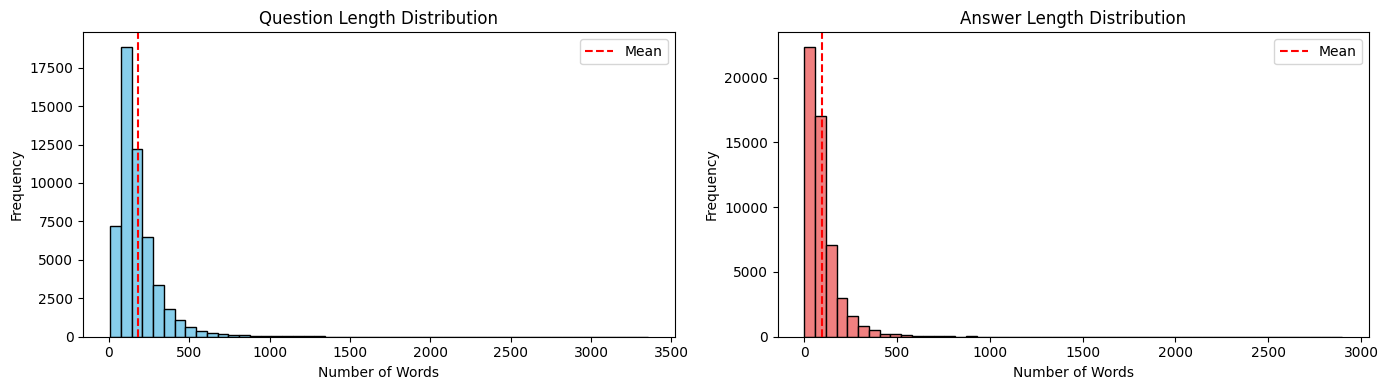


Sample Question-Answer Pairs:

Example 1:
Q: I am trying to query to insert in a table and i keep getting this message: The Query is: INSERT INTO A_USER(PK,status,login_id,HASHBYTES('md5', password),fk_role,last_update_ts,last_update_by,created_...
A: Your issue is with this line HASHBYTES('md5', password) , you want to use the HASHBYTES in the VALUES area of your INSERT . INSERT INTO A_USER ( PK ,status ,login_id ,[password] -- change to the name ...
--------------------------------------------------------------------------------

Example 2:
Q: I am using PyCharm editor 2017.3. My python version is 3.4 My main aim is to load contents from a database file into the tableView but before trying it I am trying to load contents from a test databas...
A: According to the docs : bool QSqlQuery.exec_(self, QString query) Executes the SQL in query. Returns true and sets the query state to active if the query was successful; otherwise returns false. The q...
------------------------------------

In [3]:
# Analyze lengths
train_df['question_length'] = train_df['cleaned_question'].str.split().str.len()
train_df['answer_length'] = train_df['cleaned_answer'].str.split().str.len()

print("Question Length Statistics:")
print(train_df['question_length'].describe())
print("\nAnswer Length Statistics:")
print(train_df['answer_length'].describe())

# Visualize distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(train_df['question_length'], bins=50, color='skyblue', edgecolor='black')
axes[0].set_xlabel('Number of Words')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Question Length Distribution')
axes[0].axvline(train_df['question_length'].mean(), color='red', linestyle='--', label='Mean')
axes[0].legend()

axes[1].hist(train_df['answer_length'], bins=50, color='lightcoral', edgecolor='black')
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Answer Length Distribution')
axes[1].axvline(train_df['answer_length'].mean(), color='red', linestyle='--', label='Mean')
axes[1].legend()

plt.tight_layout()
plt.show()

# Display sample Q&A pairs
print("\n" + "="*80)
print("Sample Question-Answer Pairs:")
print("="*80)
for i in range(3):
    print(f"\nExample {i+1}:")
    print(f"Q: {train_df.iloc[i]['cleaned_question'][:200]}...")
    print(f"A: {train_df.iloc[i]['cleaned_answer'][:200]}...")
    print("-"*80)

## 4. Build Vocabularies

Create word-to-index mappings for both questions and answers.

In [4]:
# Extract questions and answers
train_questions = train_df['cleaned_question'].tolist()
train_answers = train_df['cleaned_answer'].tolist()
test_questions = test_df['cleaned_question'].tolist()
test_answers = test_df['cleaned_answer'].tolist()

# Create vocabularies from ALL data (train + test)
all_questions = train_questions + test_questions
all_answers = train_answers + test_answers

(question_word2int, question_int2word,
 answer_word2int, answer_int2word) = create_qa_vocabularies(all_questions, all_answers)

print(f"\n✅ Vocabularies created!")
print(f"Question vocab size: {len(question_word2int)}")
print(f"Answer vocab size: {len(answer_word2int)}")

# Show some example words
print(f"\nSample question words: {list(question_word2int.keys())[4:14]}")
print(f"Sample answer words: {list(answer_word2int.keys())[4:14]}")


BUILDING VOCABULARIES

Unique question words: 1219548
Unique answer words: 600091

Final question vocabulary size: 20000
Final answer vocabulary size: 20000

Special tokens: ['<PAD>', '<SOS>', '<EOS>', '<UNK>']

✅ Vocabularies created!
Question vocab size: 20000
Answer vocab size: 20000

Sample question words: ['the', 'i', '=', 'to', 'and', 'a', 'is', 'in', 'from', 'as']
Sample answer words: ['the', 'to', '=', 'you', 'a', 'as', 'and', 'from', 'is', 'in']


## 5. Create DataLoaders

Prepare PyTorch DataLoaders for training.

In [5]:
# Create training dataloader
train_dataloader = create_qa_dataloader(
    train_questions, train_answers,
    question_word2int, answer_word2int,
    BATCH_SIZE, shuffle=True
)

# Create test dataloader
test_dataloader = create_qa_dataloader(
    test_questions, test_answers,
    question_word2int, answer_word2int,
    BATCH_SIZE, shuffle=False
)

# Test a batch
sample_questions, sample_answers = next(iter(train_dataloader))
print(f"\nSample batch shapes:")
print(f"Questions: {sample_questions.shape}")
print(f"Answers: {sample_answers.shape}")

Created DataLoader: 53034 samples, 1658 batches
Created DataLoader: 13259 samples, 415 batches

Sample batch shapes:
Questions: torch.Size([32, 466])
Answers: torch.Size([32, 524])


## 6. Build the Model

Initialize the LSTM Encoder-Decoder architecture.

In [6]:
# Create encoder and decoder
encoder, decoder = create_qa_model(
    len(question_word2int), 
    len(answer_word2int),
    EMBED_SIZE, 
    HIDDEN_SIZE, 
    NUM_LAYERS, 
    DEVICE
)

print("\n✅ Model created successfully!")
print(f"\nModel Configuration:")
print(f"  Embedding size: {EMBED_SIZE}")
print(f"  Hidden size: {HIDDEN_SIZE}")
print(f"  Number of layers: {NUM_LAYERS}")
print(f"  Device: {DEVICE}")


Model Architecture:
  Question Encoder: 8,798,208 parameters
  Answer Decoder:   19,058,208 parameters
  Total:            27,856,416 parameters

✅ Model created successfully!

Model Configuration:
  Embedding size: 256
  Hidden size: 512
  Number of layers: 2
  Device: cuda:0


## 7. Train the Model

Train the encoder-decoder model with teacher forcing.

In [7]:
# Training configuration
loss_fn = nn.CrossEntropyLoss(ignore_index=answer_word2int[PAD_TOKEN])
encoder_optimizer = optim.AdamW(encoder.parameters(), lr=LEARNING_RATE)
decoder_optimizer = optim.AdamW(decoder.parameters(), lr=LEARNING_RATE)

# Track losses
train_losses = []

print("="*80)
print("TRAINING STARTED")
print("="*80)

# Training loop
for epoch in range(NUM_EPOCHS):
    encoder.train()
    decoder.train()
    
    total_loss = 0
    batch_count = 0
    
    for i, (question_tensor, answer_tensor) in enumerate(train_dataloader):
        question_tensor = question_tensor.to(DEVICE)
        answer_tensor = answer_tensor.to(DEVICE)
        
        # Zero gradients
        encoder_optimizer.zero_grad()
        decoder_optimizer.zero_grad()
        
        batch_size = question_tensor.size(0)
        target_length = answer_tensor.size(1)
        
        # Encode questions
        _, encoder_hidden, encoder_cell = encoder(question_tensor)
        
        # Decode with teacher forcing
        decoder_input = torch.full(
            (batch_size, 1),
            answer_word2int[SOS_TOKEN],
            dtype=torch.long
        ).to(DEVICE)
        decoder_hidden = encoder_hidden
        decoder_cell = encoder_cell
        
        loss = 0
        
        for di in range(target_length):
            logits, decoder_hidden, decoder_cell = decoder(
                decoder_input, decoder_hidden, decoder_cell
            )
            logits = logits.squeeze(1)
            loss += loss_fn(logits, answer_tensor[:, di])
            decoder_input = answer_tensor[:, di].reshape(batch_size, 1)
        
        # Backpropagation
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(encoder.parameters(), max_norm=1.0)
        torch.nn.utils.clip_grad_norm_(decoder.parameters(), max_norm=1.0)
        
        encoder_optimizer.step()
        decoder_optimizer.step()
        
        total_loss += loss.item()
        batch_count += 1
        
        if (i + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{NUM_EPOCHS}], Batch [{i+1}/{len(train_dataloader)}], Loss: {loss.item():.4f}")
    
    avg_loss = total_loss / batch_count
    train_losses.append(avg_loss)
    
    print(f"\n{'='*80}")
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} completed - Average Loss: {avg_loss:.4f}")
    print(f"{'='*80}\n")
    
    # Save checkpoint
    if (epoch + 1) % 5 == 0:
        checkpoint = {
            'epoch': epoch,
            'encoder_state_dict': encoder.state_dict(),
            'decoder_state_dict': decoder.state_dict(),
            'encoder_optimizer_state_dict': encoder_optimizer.state_dict(),
            'decoder_optimizer_state_dict': decoder_optimizer.state_dict(),
            'question_word2int': question_word2int,
            'question_int2word': question_int2word,
            'answer_word2int': answer_word2int,
            'answer_int2word': answer_int2word,
        }
        torch.save(checkpoint, SQL_CHECKPOINT_PATH)
        print(f"✅ Checkpoint saved at epoch {epoch+1}\n")

print("✅ Training completed!")

TRAINING STARTED
Epoch [1/15], Batch [10/1658], Loss: 15742.4092
Epoch [1/15], Batch [20/1658], Loss: 1639.9395
Epoch [1/15], Batch [30/1658], Loss: 4303.1553
Epoch [1/15], Batch [40/1658], Loss: 2055.0181
Epoch [1/15], Batch [50/1658], Loss: 4571.7852
Epoch [1/15], Batch [60/1658], Loss: 1761.2483
Epoch [1/15], Batch [70/1658], Loss: 2724.8743
Epoch [1/15], Batch [80/1658], Loss: 1806.3495
Epoch [1/15], Batch [90/1658], Loss: 1992.0046
Epoch [1/15], Batch [100/1658], Loss: 1755.8591
Epoch [1/15], Batch [110/1658], Loss: 1455.9690
Epoch [1/15], Batch [120/1658], Loss: 2101.4412
Epoch [1/15], Batch [130/1658], Loss: 2029.0686
Epoch [1/15], Batch [140/1658], Loss: 1981.3363
Epoch [1/15], Batch [150/1658], Loss: 1951.5321
Epoch [1/15], Batch [160/1658], Loss: 1607.8054
Epoch [1/15], Batch [170/1658], Loss: 2463.4480
Epoch [1/15], Batch [180/1658], Loss: 1602.3621
Epoch [1/15], Batch [190/1658], Loss: 2874.7378
Epoch [1/15], Batch [200/1658], Loss: 2824.0535
Epoch [1/15], Batch [210/1658],

## 8. Visualize Training Progress

Plot the training loss over epochs.

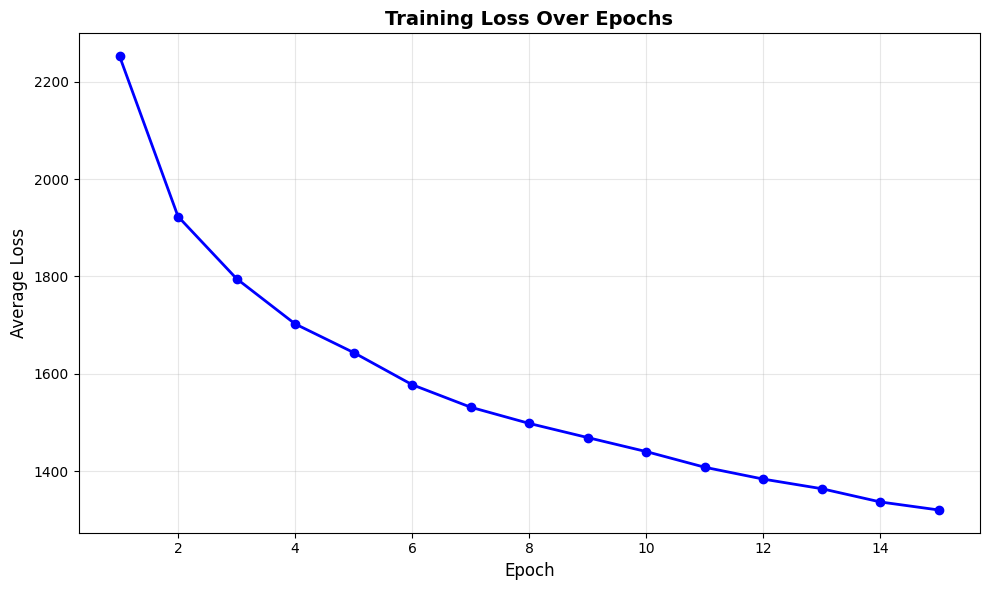

Final training loss: 1320.2717


In [8]:
# Plot training loss
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(train_losses) + 1), train_losses, marker='o', linestyle='-', color='blue', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Average Loss', fontsize=12)
plt.title('Training Loss Over Epochs', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final training loss: {train_losses[-1]:.4f}")

## 9. Evaluate and Make Predictions

Test the trained model on sample questions.

In [9]:
# Test on sample questions
print("="*80)
print("ANSWER GENERATION EXAMPLES")
print("="*80)

num_examples = 5
for i in range(min(num_examples, len(test_questions))):
    question = test_questions[i]
    true_answer = test_answers[i]
    
    # Generate answer
    generated_answer = generate_answer(
        encoder, decoder, question,
        question_word2int, answer_word2int, answer_int2word,
        max_length=200
    )
    
    print(f"\nExample {i+1}:")
    print(f"Question: {question[:150]}...")
    print(f"\nTrue Answer: {true_answer[:150]}...")
    print(f"\nGenerated Answer: {generated_answer[:150]}...")
    print("-"*80)

print("\n✅ Evaluation completed!")

ANSWER GENERATION EXAMPLES

Example 1:
Question: I have two SQL query's, when I write the second query it drops a SQL error, like this "Foreign key constraint is incorrectly formed". And I don't know...

True Answer: clients_vehicles.id_client is INT whereas clients.id_client is UNSIGNED INT . There is type mismatch. change UNSIGNED INT to INT and it will work...

Generated Answer: you can use a table in the where clause to get the <UNK> column in the table <UNK> and then use the <UNK> pseudo-column to get the <UNK> <UNK> <UNK> <...
--------------------------------------------------------------------------------

Example 2:
Question: I wanted to make an edit file form where you choose the a different file to upload and replace the previous file. This is my code. &lt;?php require("c...

True Answer: The correct coding should be Upload File: &lt;?php echo $row['filename'] ?&gt; &lt;input type="file" name="upload"/&gt;&lt;br&gt; &lt;input type="subm...

Generated Answer: you need to use t

## 10. Save Final Model

Save the trained model for future use.

In [10]:
# Save final model
final_model = {
    'encoder_state_dict': encoder.state_dict(),
    'decoder_state_dict': decoder.state_dict(),
    'question_word2int': question_word2int,
    'question_int2word': question_int2word,
    'answer_word2int': answer_word2int,
    'answer_int2word': answer_int2word,
    'config': {
        'embed_size': EMBED_SIZE,
        'hidden_size': HIDDEN_SIZE,
        'num_layers': NUM_LAYERS,
        'question_vocab_size': len(question_word2int),
        'answer_vocab_size': len(answer_word2int)
    }
}

torch.save(final_model, SQL_MODEL_PATH)
print(f"✅ Final model saved to: {SQL_MODEL_PATH}")

# Also save to checkpoint
torch.save({
    'epoch': NUM_EPOCHS - 1,
    'encoder_state_dict': encoder.state_dict(),
    'decoder_state_dict': decoder.state_dict(),
    'encoder_optimizer_state_dict': encoder_optimizer.state_dict(),
    'decoder_optimizer_state_dict': decoder_optimizer.state_dict(),
    'question_word2int': question_word2int,
    'question_int2word': question_int2word,
    'answer_word2int': answer_word2int,
    'answer_int2word': answer_int2word,
}, SQL_CHECKPOINT_PATH)
print(f"✅ Checkpoint saved to: {SQL_CHECKPOINT_PATH}")

✅ Final model saved to: ../models/sql_qa_model.pth
✅ Checkpoint saved to: ../models/sql_qa_checkpoint.pth


## 11. Interactive Testing

Test the model with custom questions.

In [11]:
# Function to test custom questions
def ask_question(question_text):
    """Generate an answer for a custom question."""
    answer = generate_answer(
        encoder, decoder, question_text,
        question_word2int, answer_word2int, answer_int2word,
        max_length=200
    )
    print(f"Q: {question_text}")
    print(f"A: {answer}")
    return answer

# Example usage
print("="*80)
print("INTERACTIVE QUESTION ANSWERING")
print("="*80)
print("\nYou can now test the model with custom questions!")
print("Modify the question below and run this cell:\n")

# Test with a custom question
custom_question = "How do I get all information from a table"
ask_question(custom_question)

INTERACTIVE QUESTION ANSWERING

You can now test the model with custom questions!
Modify the question below and run this cell:

Q: How do I get all information from a table
A: you need to use a table in the where clause to get the <UNK> column in the select list of the table <UNK> .


'you need to use a table in the where clause to get the <UNK> column in the select list of the table <UNK> .'

In [12]:
# Load saved model
saved = torch.load(SQL_MODEL_PATH, map_location=DEVICE)

# Recreate model with saved config
encoder, decoder = create_qa_model(
    saved['config']['question_vocab_size'],
    saved['config']['answer_vocab_size'],
    saved['config']['embed_size'],
    saved['config']['hidden_size'],
    saved['config']['num_layers'],
    DEVICE
)

encoder.load_state_dict(saved['encoder_state_dict'])
decoder.load_state_dict(saved['decoder_state_dict'])
encoder.eval()
decoder.eval()

question_word2int = saved['question_word2int']
question_int2word = saved['question_int2word']
answer_word2int = saved['answer_word2int']
answer_int2word = saved['answer_int2word']

# Ask a simple SQL-related question
custom_question = "How do I select all rows from a table?"
generated_answer = generate_answer(
    encoder, decoder, custom_question,
    question_word2int, answer_word2int, answer_int2word,
    max_length=200
)

print(f"Q: {custom_question}")
print(f"A: {generated_answer}")


Model Architecture:
  Question Encoder: 8,798,208 parameters
  Answer Decoder:   19,058,208 parameters
  Total:            27,856,416 parameters
Q: How do I select all rows from a table?
A: you need to use a table alias to get the <UNK> column names and the <UNK> table as a column name. you can use a table alias to get the <UNK> column names and the <UNK> table as a column name.


In [4]:
# Load saved model
saved = torch.load(SQL_MODEL_PATH, map_location=DEVICE)

# Recreate model with saved config
encoder, decoder = create_qa_model(
    saved['config']['question_vocab_size'],
    saved['config']['answer_vocab_size'],
    saved['config']['embed_size'],
    saved['config']['hidden_size'],
    saved['config']['num_layers'],
    DEVICE
)

encoder.load_state_dict(saved['encoder_state_dict'])
decoder.load_state_dict(saved['decoder_state_dict'])
encoder.eval()
decoder.eval()

question_word2int = saved['question_word2int']
question_int2word = saved['question_int2word']
answer_word2int = saved['answer_word2int']
answer_int2word = saved['answer_int2word']

# Ask a simple SQL-related question
custom_question = "How do I select all rows from a table?"
generated_answer = generate_answer(
    encoder, decoder, custom_question,
    question_word2int, answer_word2int, answer_int2word,
    max_length=200
)

print(f"Q: {custom_question}")
print(f"A: {generated_answer}")


Model Architecture:
  Question Encoder: 12,638,208 parameters
  Answer Decoder:   30,593,208 parameters
  Total:            43,231,416 parameters
  Dropout:          0.3


AssertionError: LSTM: Expected input to be 2-D or 3-D but received 4-D tensor

In [2]:
# Load saved model
saved = torch.load(SQL_MODEL_PATH, map_location=DEVICE)

# Recreate model with saved config
encoder, decoder = create_qa_model(
    saved['config']['question_vocab_size'],
    saved['config']['answer_vocab_size'],
    saved['config']['embed_size'],
    saved['config']['hidden_size'],
    saved['config']['num_layers'],
    DEVICE
)

encoder.load_state_dict(saved['encoder_state_dict'])
decoder.load_state_dict(saved['decoder_state_dict'])
encoder.eval()
decoder.eval()

question_word2int = saved['question_word2int']
question_int2word = saved['question_int2word']
answer_word2int = saved['answer_word2int']
answer_int2word = saved['answer_int2word']

# Ask a simple SQL-related question
custom_question = "How do I select all rows from a table?"
generated_answer = generate_answer(
    encoder, decoder, custom_question,
    question_word2int, answer_word2int, answer_int2word,
    max_length=200
)

print(f"Q: {custom_question}")
print(f"A: {generated_answer}")


Model Architecture:
  Question Encoder: 12,638,208 parameters
  Answer Decoder:   30,593,208 parameters
  Total:            43,231,416 parameters
  Dropout:          0.3
Q: How do I select all rows from a table?
A: you can use the following query: select * from where = and =


In [3]:
# Other questions for testing

In [4]:
test_questions = [
    # Level 1: Simple SELECT
    "How do I select all rows from a table?",
    "Show all records from users",
    
    # Level 2: Column selection
    "Get name and age from users",
    "Select email from customers",
    
    # Level 3: WHERE conditions
    "Get users with age greater than 18",
    "Show customers from Ghana",
    
    # Level 4: Multiple conditions
    "Get users older than 18 and from Ghana",
    "Find products with price greater than 50 and quantity less than 10",
    
    # Level 5: Sorting
    "Sort users by age descending",
    "Show products ordered by price ascending",
    
    # Level 6: Aggregation
    "Count number of users",
    "Get average price of products",
    
    # Level 7: Grouping
    "Count users by country",
    "Get number of orders per customer",
    
    # Level 8: Joins (likely weak)
    "Get users and their orders",
    "Show customer names and order amounts",
    
    # Level 9: Nested queries (very hard)
    "Get users who have placed orders",
    "Find products more expensive than average price"
]

In [5]:
results = []

for q in test_questions:
    generated_answer = generate_answer(
        encoder, decoder, q,
        question_word2int, answer_word2int, answer_int2word,
        max_length=200
    )
    
    results.append((q, generated_answer))

# Print nicely
for i, (q, a) in enumerate(results, 1):
    print(f"Example {i}")
    print(f"Q: {q}")
    print(f"A: {a}")
    print()

Example 1
Q: How do I select all rows from a table?
A: you can use the following query: select * from where = and =

Example 2
Q: Show all records from users
A: you can use the following query: select * from where = and =

Example 3
Q: Get name and age from users
A: you can use the following query: select * from where = and =

Example 4
Q: Select email from customers
A: you need to use a subquery to get the result set from the select list.

Example 5
Q: Get users with age greater than 18
A: you can use a subquery to get the result of the query to be the same as the following query: select * from where = and = and = and = and = and = and = and = and = and = and = and = and = and = and = and = and = and = and = and = and = and = and = and = and = and = and = and = and = and = and = and = and = and = and = and = and = and = and = and = and = and = and = and =

Example 6
Q: Show customers from Ghana
A: you can use a subquery to get the result of the query to be executed in the select claus